# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
|Vincent Valentino|5054251016|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import zscore

In [2]:
diabetes = pd.read_csv("diabetes.csv")
diabetes.shape

(768, 9)

In [3]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
diabetes.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [5]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes.duplicated().sum()

np.int64(0)

In [7]:
diabetes.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

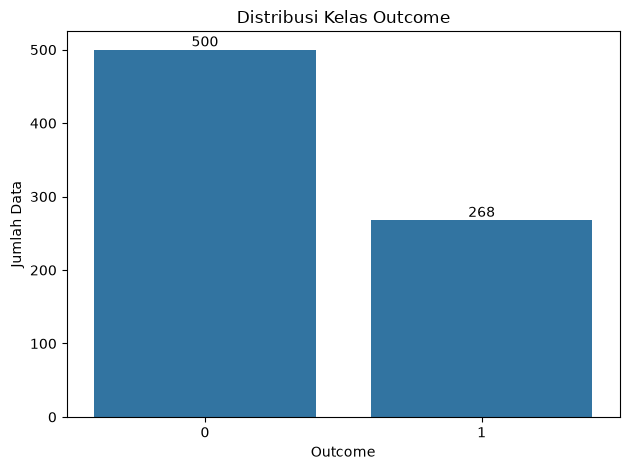

In [8]:
values = diabetes["Outcome"].value_counts().sort_index().reset_index()
ax = sb.barplot(data=values, x="Outcome", y="count")
ax.set_title("Distribusi Kelas Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("Jumlah Data")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

Kelas `Outcome` tidak seimbang, dengan 500 data non-diabetes
(65,10%) dan 268 data diabetes (34,90%). Meskipun tidak ekstrem,
ketidakseimbangan ini perlu diperhatikan saat pembagian data dan
evaluasi model.

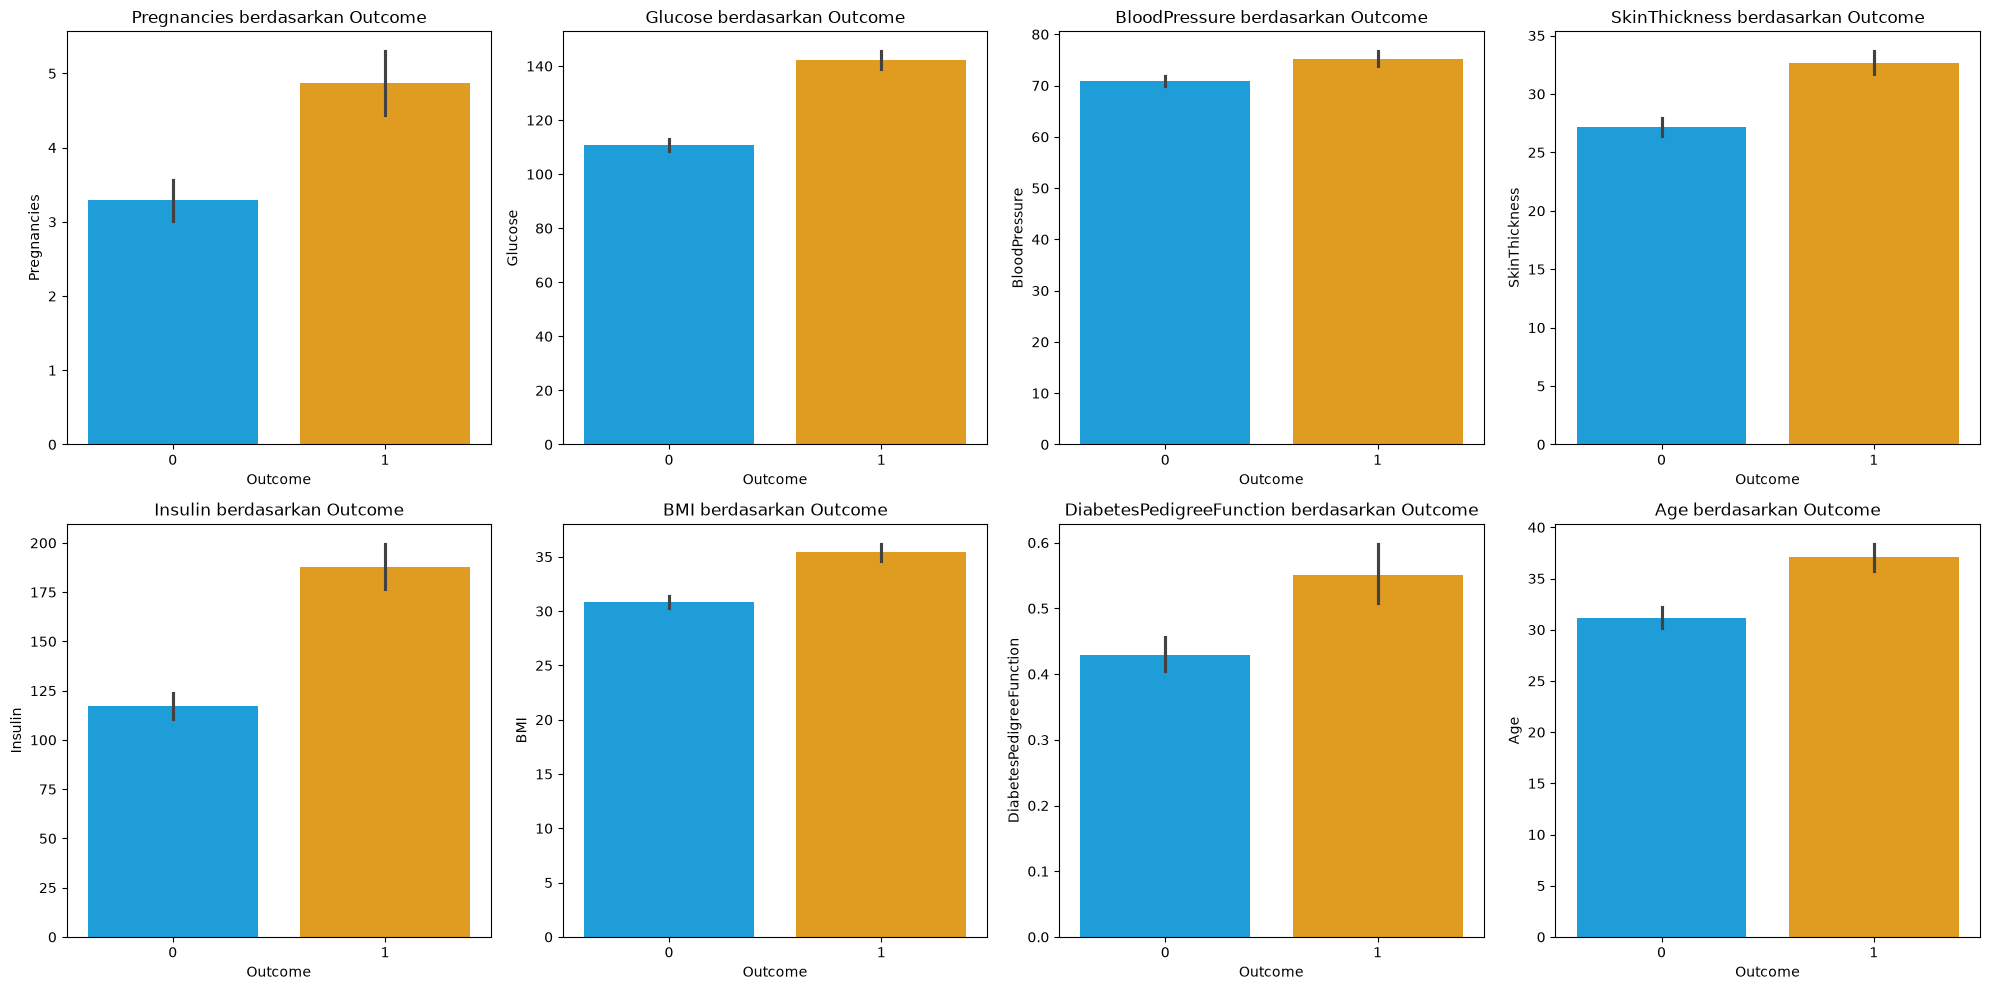

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

features = diabetes.drop(columns = "Outcome")

for ax, col in zip(axes, features):
    sb.barplot(data=diabetes, x='Outcome', y=col, hue='Outcome', palette={0: "#00A8F7", 1: "#FFA600D5"}, legend=False, ax=ax)
    ax.set_title(f'{col} berdasarkan Outcome')
    ax.set_xlabel('Outcome')
    ax.set_ylabel(col)

fig.tight_layout()
plt.show()

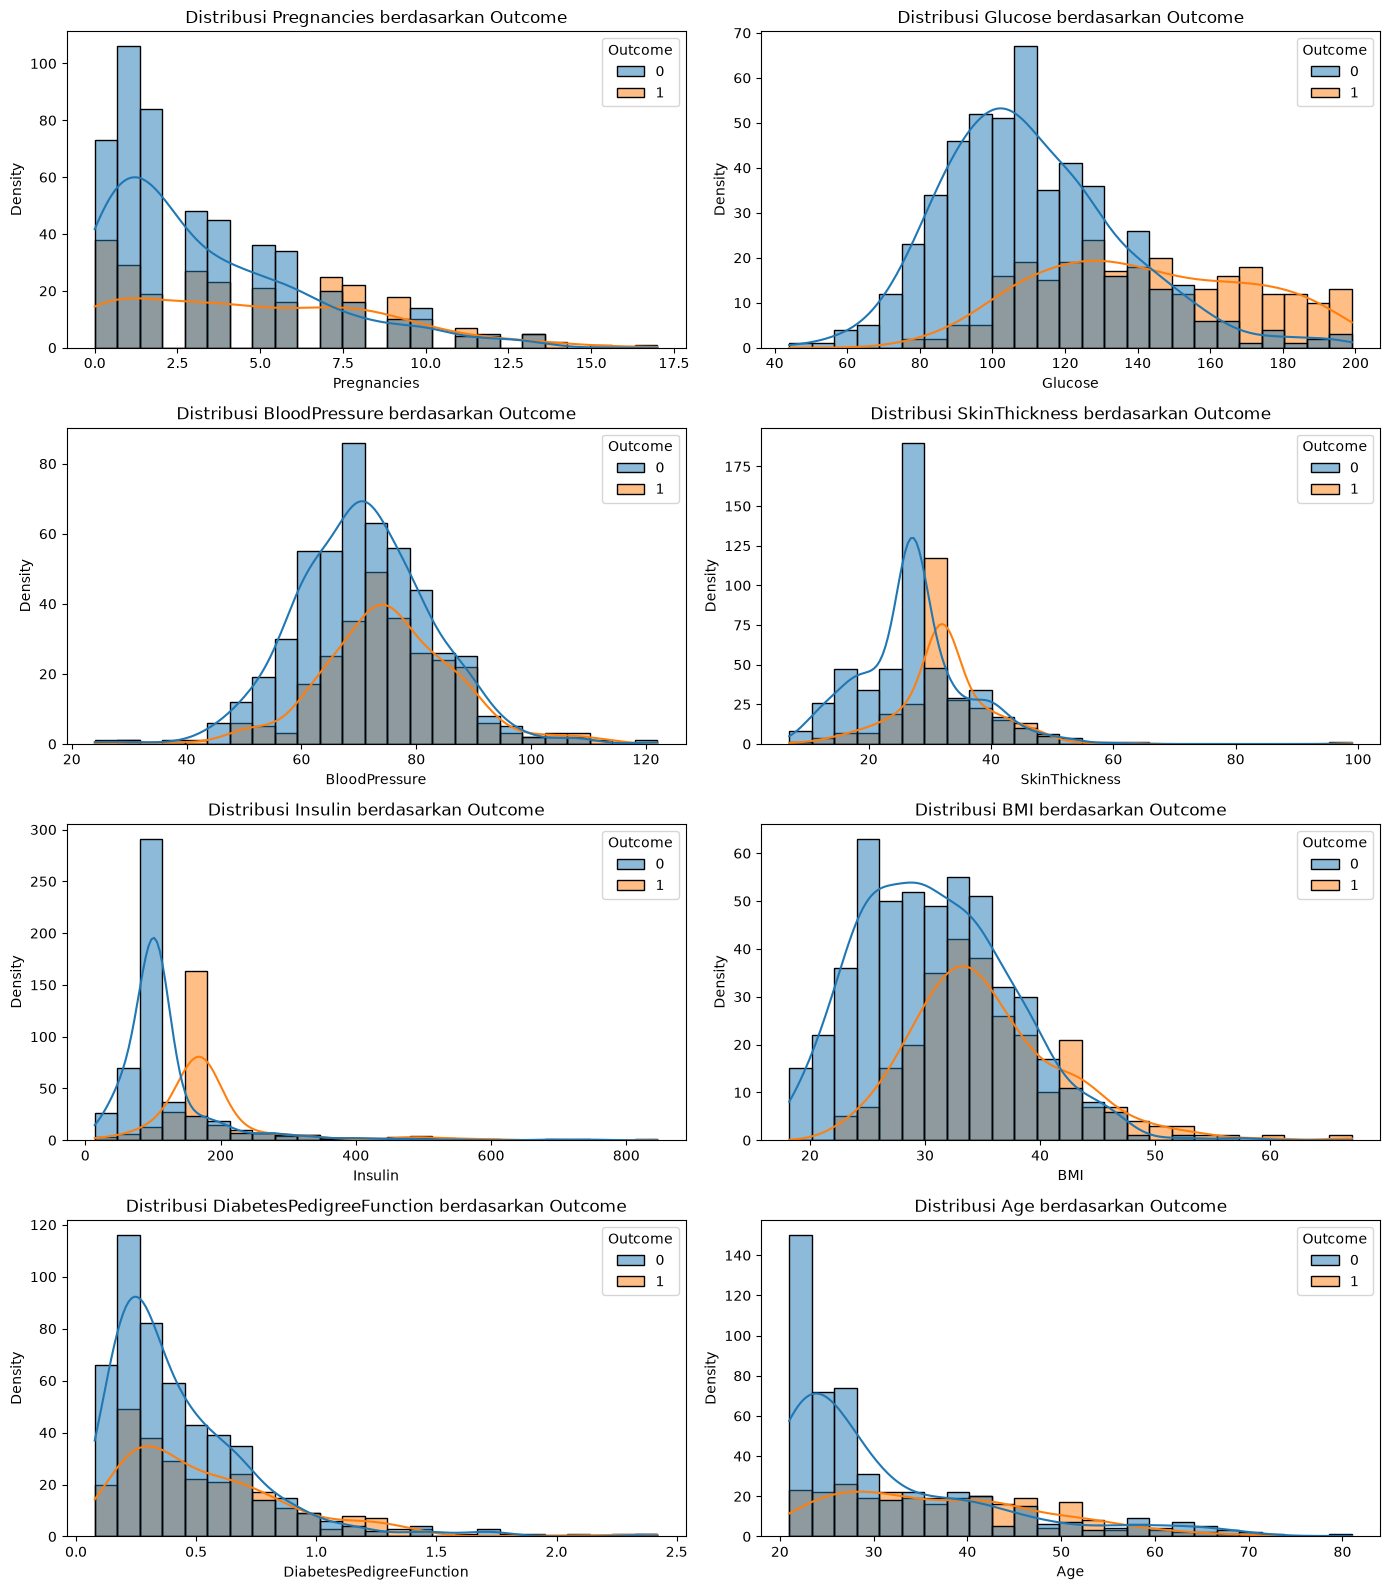

In [10]:
features = diabetes.drop(columns="Outcome")
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for ax, feature in zip(axes, features):
    sb.histplot(data=diabetes, x=feature, hue="Outcome", kde=True, bins=25, ax=ax)
    ax.set_title(f"Distribusi {feature} berdasarkan Outcome")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

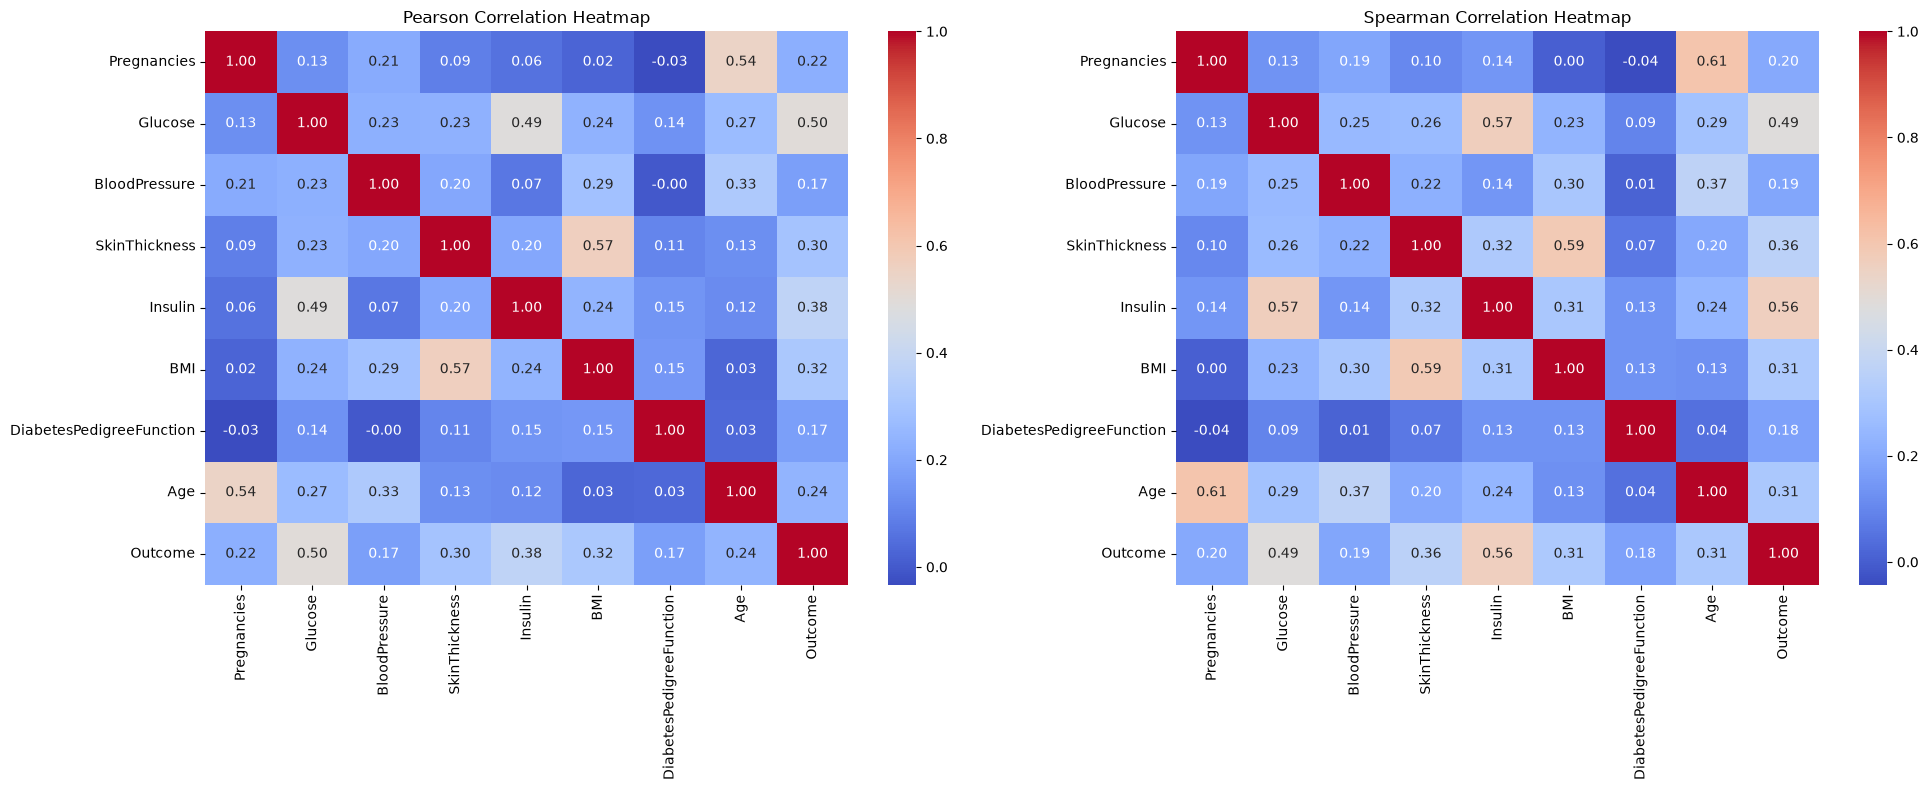

In [11]:
pearson = diabetes.corr(method="pearson")
spearman = diabetes.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sb.heatmap(pearson, annot=True, cmap="coolwarm", fmt=".2f",ax=axes[0])
axes[0].set_title("Pearson Correlation Heatmap")

sb.heatmap(spearman, annot=True, cmap="coolwarm",fmt=".2f",ax=axes[1])
axes[1].set_title("Spearman Correlation Heatmap")

plt.tight_layout()
plt.show()

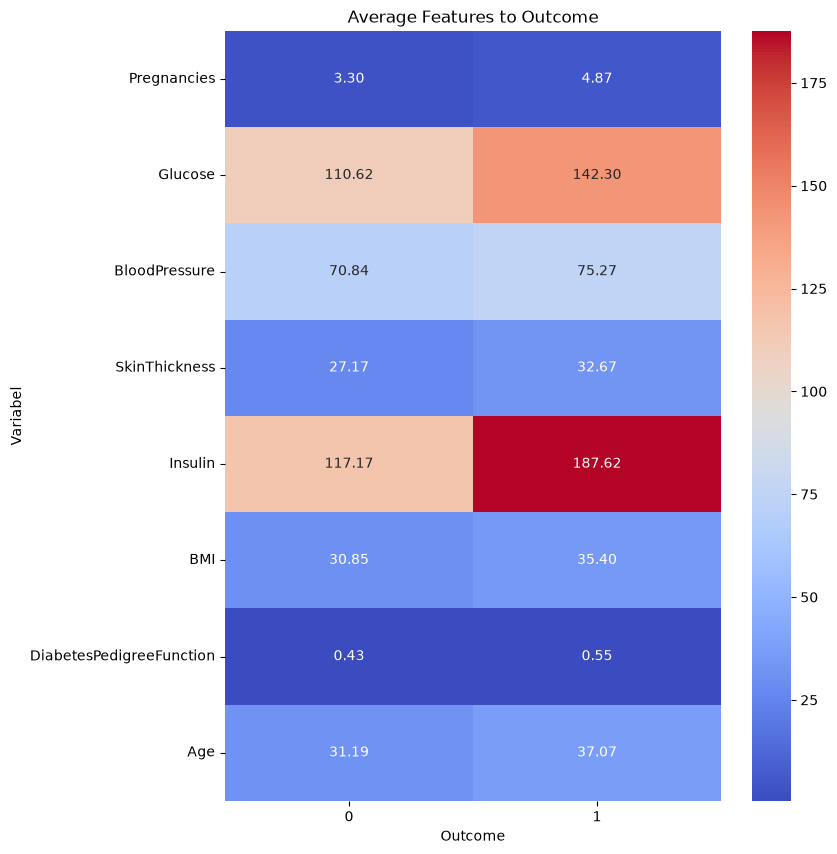

In [31]:
mean = diabetes.groupby('Outcome').mean().T
plt.figure(figsize=(8, 10))
sb.heatmap(mean, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Average Features to Outcome")
plt.xlabel("Outcome")
plt.ylabel("Variabel")

plt.show()

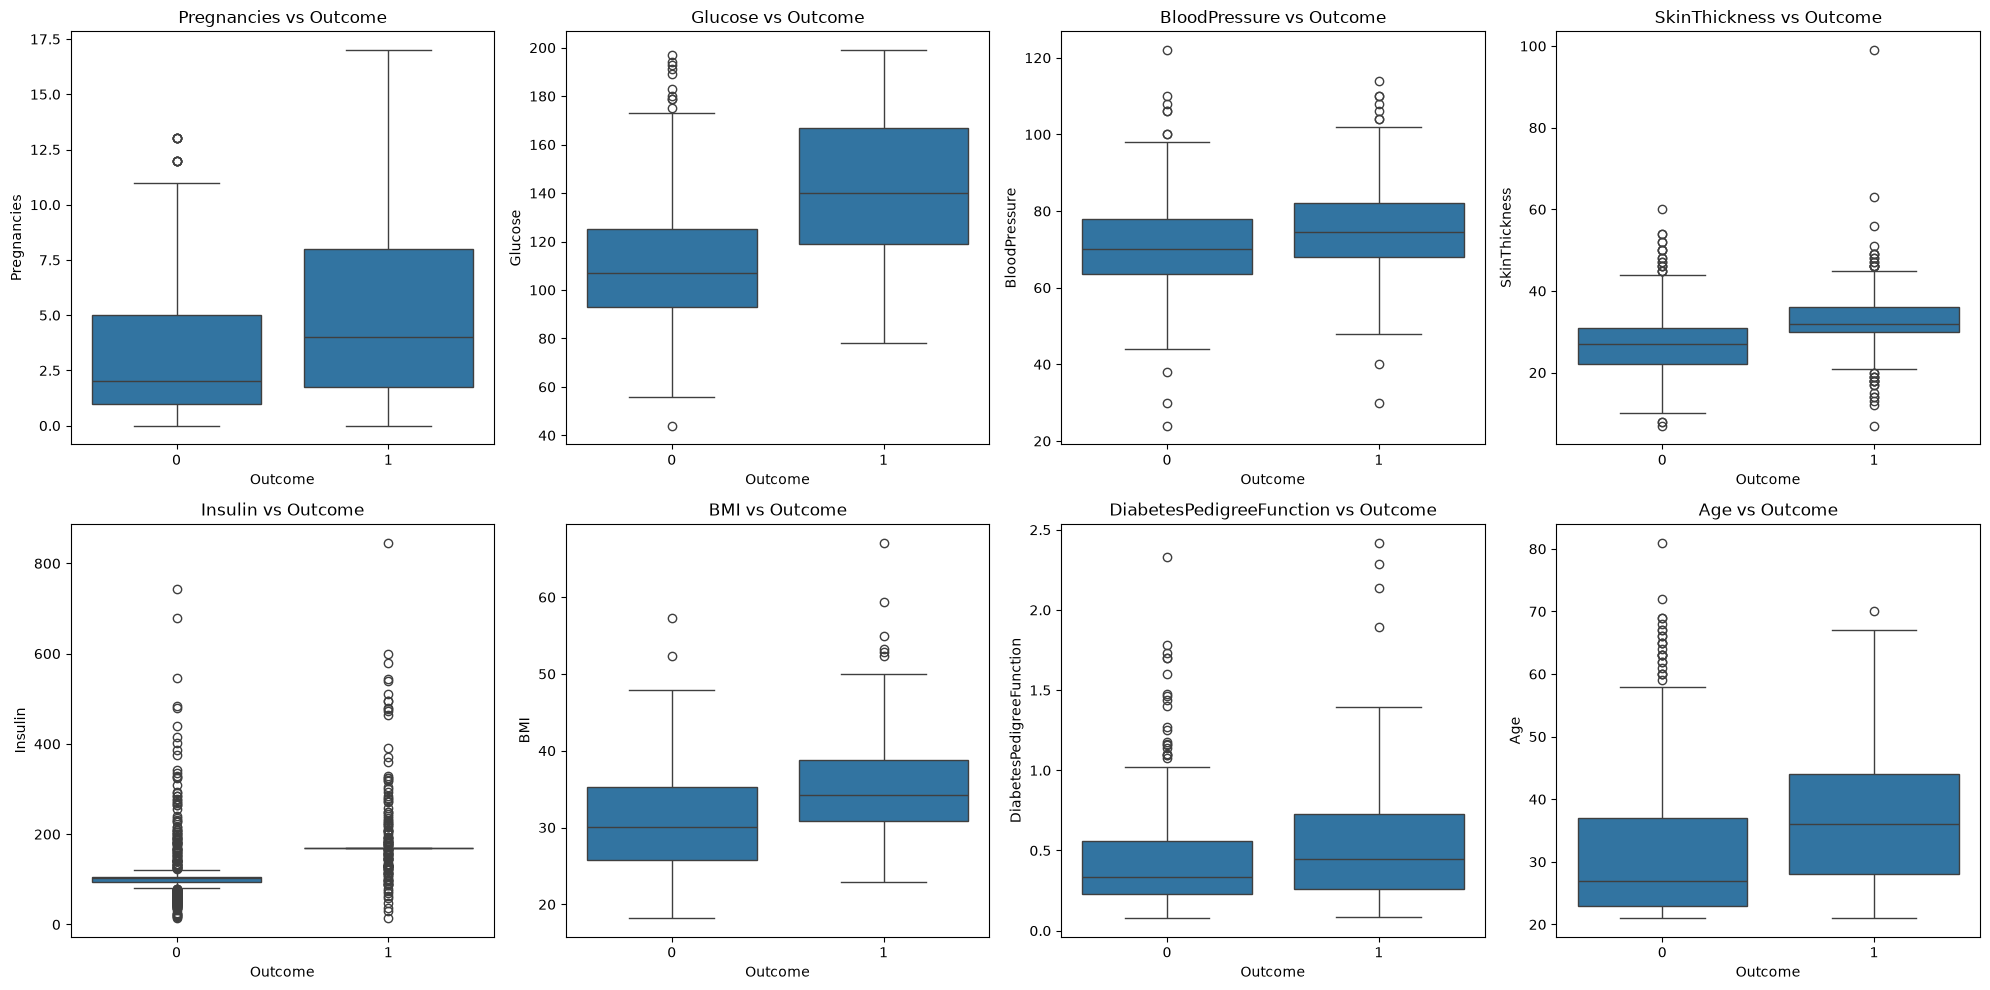

In [12]:
features = diabetes.drop(columns="Outcome")

figure, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, column in zip(axes, features):
    sb.boxplot(data=diabetes, x="Outcome", y=column, ax=ax)
    ax.set_title(f"{column} vs Outcome")

plt.tight_layout()
plt.show()

Berdasarkan boxplot, distribusi insulin sangat janggal dibandingkan fitur-fitur lain, maka akan diperdalam terlebih dahulu.

In [37]:
Q1 = diabetes['Insulin'].quantile(0.25)
Q3 = diabetes['Insulin'].quantile(0.75)

IQR = Q3 - Q1

extreme_upper = Q3 + 3 * IQR
extreme_lower = Q1 - 3 * IQR

extreme_outliers = diabetes[(diabetes['Insulin'] > extreme_upper) |(diabetes['Insulin'] < extreme_lower)]

print(f"Extreme outliers: {len(extreme_outliers)}")
print(f"Upper threshold: {extreme_upper:.2f}")

extreme_outliers[['Insulin', 'Outcome']].sort_values('Insulin', ascending=False)

Extreme outliers: 23
Upper threshold: 370.50


,Insulin,Outcome
13,846.0,1
228,744.0,0
247,680.0,0
584,600.0,1
409,579.0,1
286,545.0,0
8,543.0,1
655,540.0,1
753,510.0,1
186,495.0,1


# 2. Preprocessing

In [14]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
(diabetes[cols] <= 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Karena tidak ada nilai 0 pada dataset, sehingga tidak perlu di handling.

In [15]:
x = diabetes.drop(columns="Outcome")
y = diabetes["Outcome"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=69, stratify=y)

In [16]:
scaler = StandardScaler()
train_scale = scaler.fit_transform(x_train)
test_scale = scaler.transform(x_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [17]:
gnb =  GaussianNB()
gnb.fit(train_scale, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.17,-0.35,-0.14,...,-0.21,-0.11,-0.19], [ 0.32, 0.66, 0.26,..., 0.39, 0.2 , 0.35]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.67,0.96,...,0.91,0.85,0.98], [1.19,0.95,0.98,...,0.94,1.22,0.85]]"


In [18]:
gnb_pred = gnb.predict(test_scale)
gnb_prob = gnb.predict_proba(test_scale)[:, 1]

## 3.2 Logistic Regression

In [19]:
logreg = LogisticRegression(random_state=23)
logreg.fit(train_scale, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",23
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [20]:
log_pred = logreg.predict(test_scale)
log_prob = logreg.predict_proba(test_scale)[:, 1]

# 4. Evaluasi Model

In [21]:
predictions = {
    "Gaussian NB": gnb_pred,
    "Logistic Regression": log_pred
}

probabilities = {
    "Gaussian NB": gnb_prob,
    "Logistic Regression": log_prob   
}

metrics = []
for model in predictions.keys():
    predict = predictions[model]
    probability = probabilities[model]

    metrics.append({
        "Model": model,
        "Accuracy": accuracy_score(y_test, predict),
        "Precision": precision_score(y_test, predict, pos_label=1, zero_division=0),
        "Recall": recall_score(y_test, predict, pos_label=1, zero_division=0),
        "F1-Score": f1_score(y_test, predict, pos_label=1, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probability)
    })
    
metrics = pd.DataFrame(metrics).set_index("Model")
metrics.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Gaussian NB,0.7922,0.7619,0.5926,0.6667,0.8778
Logistic Regression,0.8052,0.8333,0.5556,0.6667,0.9013


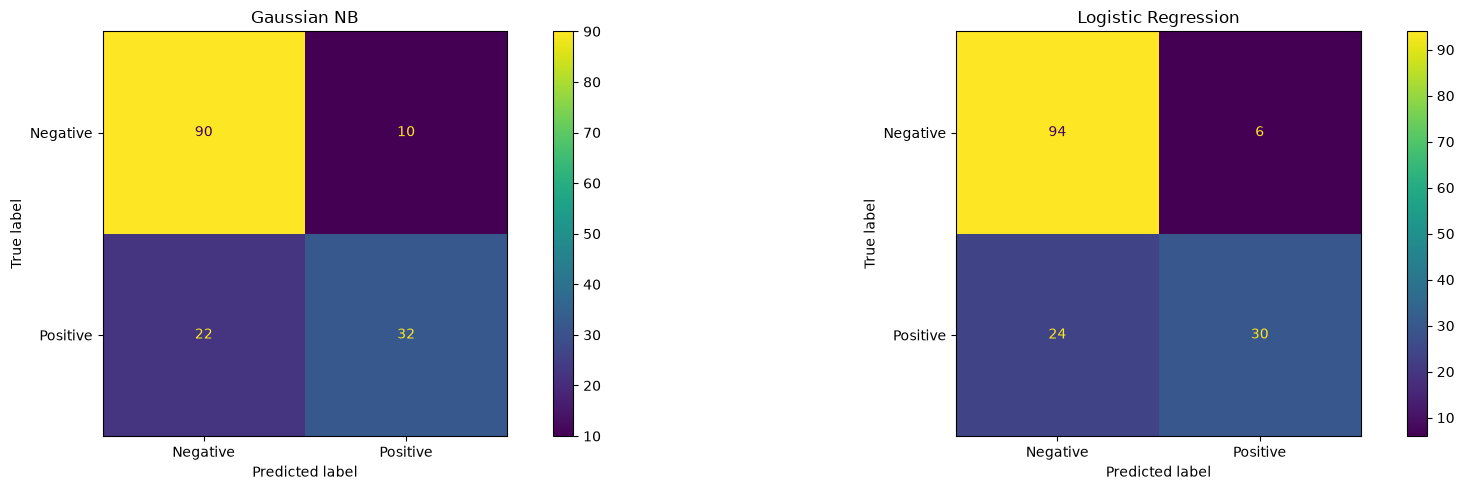

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes = axes.flatten()

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

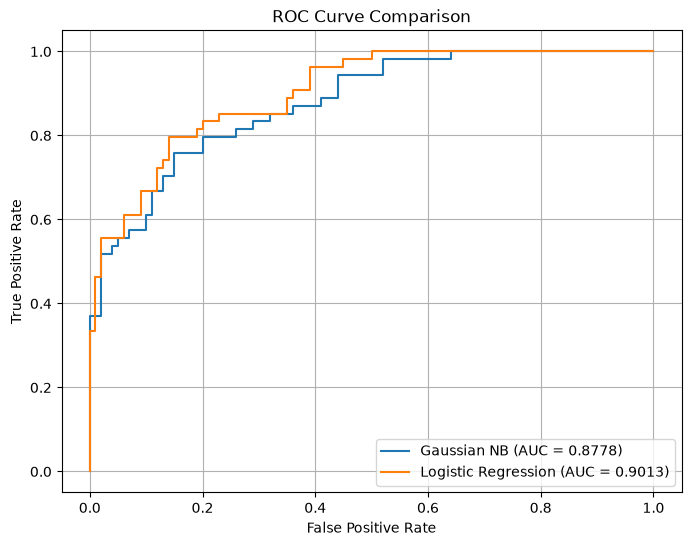

In [23]:
plt.figure(figsize=(8, 6))

for model, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model} (AUC = {auc_score:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.savefig("roc.png", dpi=300)
plt.show()

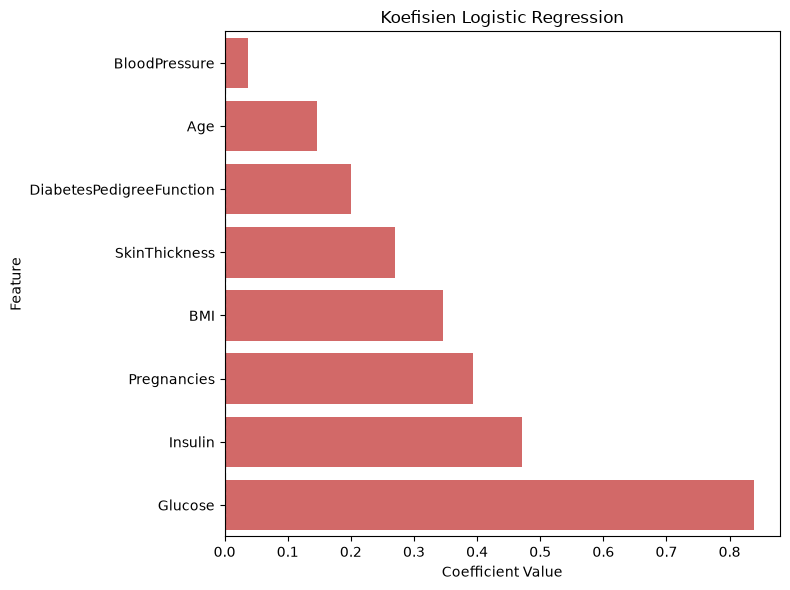

In [24]:
coefficient = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': logreg.coef_[0]
})
coefficient = coefficient.sort_values('Coefficient')
colors = ['#E45756' if x > 0 else '#4C78A8'
          for x in coefficient['Coefficient']]
plt.figure(figsize=(8, 6))

sb.barplot(
    data=coefficient,
    x='Coefficient',
    y='Feature',
    hue='Feature',
    palette=colors,
    legend=False
)
plt.axvline(0, color='black', linestyle='--')
plt.title('Koefisien Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 5. Analisis

Pada eksperimen ini dilakukan perbandingan dua algoritma klasifikasi, yaitu Gaussian Naive Bayes dan Logistic Regression, untuk memprediksi status diabetes pada Pima Indians Diabetes Dataset. Berdasarkan eksplorasi data, ditemukan bahwa distribusi kelas pada variabel Outcome tidak seimbang. Terdapat 500 data non-diabetes (65,10%) dan 268 data diabetes (34,90%).

Visualisasi rata-rata fitur terhadap Outcome menunjukkan bahwa kelompok pasien diabetes cenderung memiliki nilai Glucose, BMI, Insulin, Age, dan DiabetesPedigreeFunction yang lebih tinggi dibandingkan kelompok non-diabetes. Selain itu, heatmap korelasi memperlihatkan bahwa Glucose memiliki hubungan paling kuat dengan variabel target dibandingkan fitur lainnya. Temuan ini menunjukkan bahwa kadar glukosa merupakan indikator penting dalam proses klasifikasi diabetes.

Berdasarkan boxplot, fitur Insulin memiliki pola distribusi yang paling berbeda dibandingkan fitur lainnya. Oleh karena itu dilakukan analisis lanjutan menggunakan metode Interquartile Range (IQR). Hasilnya menunjukkan terdapat 23 extreme outlier pada variabel Insulin dengan batas atas sebesar 370,50. Beberapa observasi memiliki nilai Insulin yang sangat tinggi, bahkan mencapai 846. Nilai-nilai tersebut jauh berada di atas mayoritas distribusi data sehingga dapat memengaruhi proses pembelajaran model. Namun, karena nilai tersebut masih mungkin terjadi secara medis dan jumlahnya relatif kecil dibandingkan keseluruhan dataset, outlier tidak dihapus agar informasi penting tetap dipertahankan.

Hasil evaluasi menunjukkan bahwa Logistic Regression menghasilkan Accuracy sebesar **80,52%**, lebih tinggi dibandingkan Gaussian Naive Bayes sebesar **79,22%**. Logistic Regression juga memiliki Precision (**0,8333**) dan ROC-AUC (**0,9013**) yang lebih tinggi, sedangkan Gaussian Naive Bayes memiliki Recall yang sedikit lebih baik (**0,5926**). Kedua model memperoleh F1-Score yang sama, yaitu **0,6667**.

Berdasarkan ROC-AUC, Logistic Regression memiliki kemampuan diskriminasi yang lebih baik dalam membedakan pasien diabetes dan non-diabetes pada berbagai nilai threshold. Kurva ROC juga memperlihatkan bahwa performa Logistic Regression secara konsisten lebih baik dibandingkan Gaussian Naive Bayes.

Analisis koefisien Logistic Regression menunjukkan bahwa fitur Glucose memberikan kontribusi positif terbesar terhadap prediksi diabetes, diikuti oleh BMI, Insulin, Pregnancies, dan Age. Hasil ini sejalan dengan temuan pada tahap eksplorasi data yang menunjukkan bahwa pasien diabetes umumnya memiliki kadar glukosa dan indikator kesehatan metabolik yang lebih tinggi dibandingkan pasien non-diabetes. Oleh karena itu, dapat disimpulkan bahwa Glucose merupakan faktor yang paling berpengaruh dalam proses klasifikasi pada dataset ini.

Secara keseluruhan, kedua model mampu memberikan performa klasifikasi yang baik meskipun terdapat ketidakseimbangan kelas dan keberadaan outlier pada fitur Insulin. Namun, berdasarkan Accuracy, Precision, dan ROC-AUC, Logistic Regression menunjukkan performa yang lebih unggul sehingga dapat dianggap sebagai model terbaik pada eksperimen ini. Sementara itu, Gaussian Naive Bayes tetap menjadi alternatif yang baik apabila prioritas utama adalah meningkatkan kemampuan deteksi kasus diabetes melalui nilai Recall yang lebih tinggi.

# 6. Kesimpulan dan Saran

#### Kesimpulan

Berdasarkan hasil eksperimen, baik Gaussian Naive Bayes maupun Logistic Regression mampu melakukan klasifikasi diabetes dengan performa yang cukup baik. Logistic Regression memperoleh hasil yang lebih unggul dengan Accuracy sebesar 80,52% dan ROC-AUC sebesar 0,9013, sedangkan Gaussian Naive Bayes memperoleh Accuracy sebesar 79,22% dan ROC-AUC sebesar 0,8778. Selain itu, Logistic Regression memiliki Precision yang lebih tinggi, sementara Gaussian Naive Bayes memiliki Recall yang sedikit lebih baik.

Meskipun ditemukan 23 extreme outlier pada fitur Insulin, kedua model tetap mampu menghasilkan performa yang baik. Secara keseluruhan, Logistic Regression dapat dianggap sebagai model terbaik pada dataset ini karena memiliki kemampuan klasifikasi dan diskriminasi kelas yang lebih baik dibandingkan Gaussian Naive Bayes.

#### Saran

Beberapa pengembangan yang dapat dilakukan pada eksperimen selanjutnya adalah:
1. Mencoba teknik penanganan class imbalance seperti SMOTE atau class weighting untuk meningkatkan kemampuan model dalam mendeteksi pasien diabetes.
2. Mencoba penanganan outlier pada fitur Insulin dan membandingkan dampaknya terhadap performa model.
3. Melakukan hyperparameter tuning untuk memperoleh konfigurasi model yang lebih optimal.